# An OU approximation for fBm with $H < \frac12$

----------------------------------------------------------------------------
In this notebook we implement and validate an the OU approximation of fBm using a geometric discretization of the Muravlev rperesntation


# Simple Simulation of the OU process

So for the standard OU process used in our report we have the transition probability being exactly $$Z_t^{\beta} | Z_s^{\beta} = N \left ( e^{- \beta (t -s)Z_s^{\beta}}, \frac{1 - e^{-2 \beta(t-s)}}{2 \beta} \right ) $$
 So we use the exact discretization:
 $$Z_{t + \Delta t} = e^{- \beta \Delta t}Z_t + \frac{1 - e^{-2 \beta(\Delta t)}}{2 \beta} W$$
 where $ W \sim N(0,1)$

 We can start the process at $Z_0 = 0$..

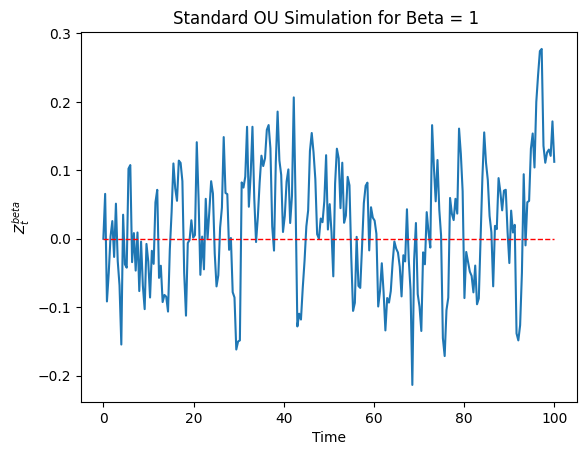

In [2]:
import numpy as np
import matplotlib.pyplot as plt

n = 252
t = 100
dt = t/n
times = np.linspace(0, t, n)
beta = 1

W = np.random.normal(0, dt, n)


Z = np.zeros(n)
Z[0] = 0 # start at z_0 = 0 which can be changed to start from any point
for i in range(1, n):
    Z[i] = np.exp(-beta * dt) * Z[i-1] + (1 - np.exp(-beta * dt))/ (2* beta) * W[i]
    

plt.plot(times, Z)
plt.title(f"Standard OU Simulation for Beta = {beta} ")
plt.hlines(0, color='r', linestyle='--', linewidth=1, xmin=0, xmax=t)
plt.xlabel("Time")
plt.ylabel("$Z^{beta}_t$")
plt.show()

# A More General OU Simulation

We will next generalise the above simulation in two ways.

- First of all we will remove the assmuption that it starts at the origin and have it start at $-\infty$ to make the process stationary.

- Next we will be simulating $n$ correlated OU processes - this is what we will later need for fBm. To do this we account for $Z_0^{\beta_i} = \int_{-\infty}^0 e^{\beta_i u} dB_u$ for each $i = 1 , \dots, n$. Note that each $Z_0^{\beta_i} \sim N(0, \frac1{2 \beta_i})$ with $cov(Z_0^{\beta_i}, Z_0^{\beta_j}) = \frac1{\beta_i + \beta_j}$. Thus we can simply use the Cholesky method to simulate this multivariate Gaussian.

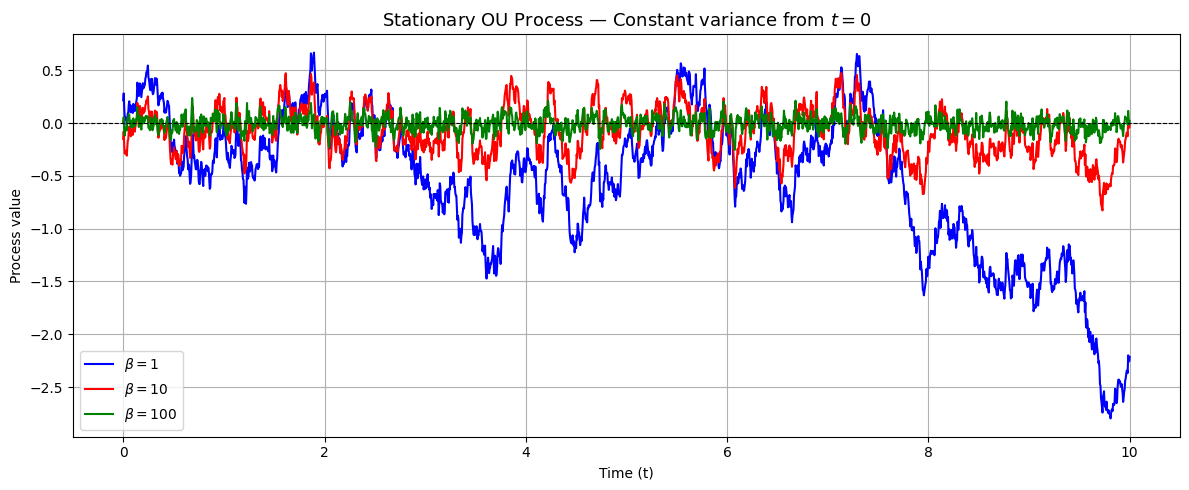

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_OU_paths(beta, T, n_steps, M, rng, stationary_start=True):
    """
    Simulate M paths of the OU process for each rate in `beta`, jointly,
    all driven by the SAME scalar Brownian increments per path.

    Returns array of shape (M, n_steps+1, len(beta)).
    """
    beta = np.asarray(beta)
    
    dt = T / n_steps
    decay = np.exp(-beta * dt)
    scale = np.sqrt((1 - np.exp(-2 * beta * dt)) / (2 * beta))

    Z = np.zeros((M, len(beta)))
    if stationary_start:
        Gamma = 1.0 / (beta[:, None] + beta[None, :])
        L = np.linalg.cholesky(Gamma + 1e-12 * np.eye(len(beta)))
        Z = rng.normal(size=(M, len(beta))) @ L.T

    Z_path = np.zeros((M, n_steps + 1, len(beta)))
    Z_path[:, 0, :] = Z

    for i in range(n_steps):
        noise = rng.normal(size=M)
        Z = decay[None, :] * Z + scale[None, :] * noise[:, None]
        Z_path[:, i + 1, :] = Z

    return Z_path

# ---------- Parameters ----------
T = 10
n_steps = 2000
betas = [1, 10, 100]      # can be a list – the function now converts it
M = 1
rng = np.random.default_rng(42)

# Simulate stationary fBm only
paths = simulate_OU_paths(betas, T, n_steps, M, rng, stationary_start=True)[0]  # shape: (steps, 3)

t = np.linspace(0, T, n_steps + 1)
colors = ['blue', 'red', 'green']
labels = [f'$\\beta = {b}$' for b in betas]

# ---------- Plot ----------
plt.figure(figsize=(12, 5))
for i in range(len(betas)):
    plt.plot(t, paths[:, i], color=colors[i], label=labels[i])

plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Stationary OU Process — Constant variance from $t=0$', fontsize=13)
plt.xlabel('Time (t)')
plt.ylabel('Process value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



# The Fractional Kernel Approximation

The key part of the OU represntation for fBm uses fact that
$$(t-u)^{H - \frac12} = \frac{1}{\Gamma(\frac12 - H)} \int_0^{\infty} \beta^{-\frac12 - H} e^{-(t-u)} d \beta$$
Hence we can approximate our kernel $$ K(t,u) = (t - u)^{H - \frac12} \approx \sum_i w_j e^{-(t-u) \beta_j} $$ 

We choose a geometric quadrature $\beta_j = r^{j}$ for $r \in (1,2)$ (accounts for the fact that larger $\beta$ is faster mean reverting so shorter time scale ). Note $j = - n + 1, \dots, n$

So under this discretization we have $$w_j = \frac1{\Gamma \left (\frac12 - H \right) } \int_{r^{j - 1}}^{r^j} x^{-\frac12 - H} dx$$ Hence $$w_j = \frac1{\Gamma(\frac12 - H)} r^{j - 1(\frac12 - H)} \left [ \frac{r^{\frac12 - H} - 1}{\frac12 - H} \right ] $$

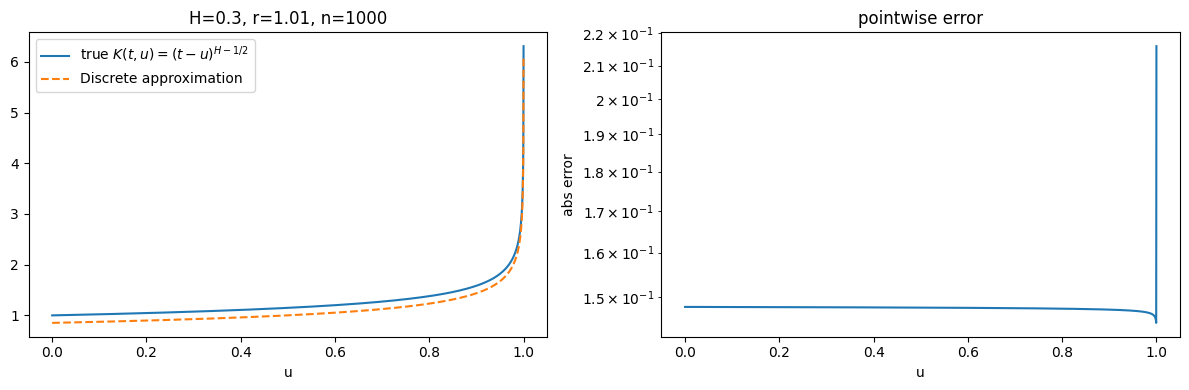

In [4]:
import numpy as np
from scipy.special import gamma
import matplotlib.pyplot as plt

def OU_weights(H, r, n):
    """
    Nodes beta_j = r^{j-1} and weights w_j for j = -n+1,...,n,
    approximating (t-u)^{H-1/2} = (1/Gamma(1/2-H)) * int_0^inf x^{-H-1/2} e^{-x(t-u)} dx.
    """
    a = H + 0.5
    j = np.arange(-n + 1, n + 1)          # 2n values: -n+1, ..., n
    beta = r**(j - 1)
    weights = (1/gamma(0.5 - H)) * r**((1 - a)*(j - 1)) * (r**(1 - a) - 1)/(1 - a)
    return beta, weights

def kernel_true(t, u, H):
    return (t - u) ** (H - 0.5)

def kernel_approx(t, u, H, n, r):
    beta, weights = OU_weights(H, r, n)  
    du = (t - u)[:, None]                
    return np.sum(weights[None, :] * np.exp(-beta[None, :] * du), axis=1)

# --- example ---
H = 0.3
t = 1.0
r = 1.01
n = 1000

u = np.linspace(0, t - 1e-4, 2000)
f_true = kernel_true(t, u, H)
f_hat  = kernel_approx(t, u, H, n, r)
err = np.abs(f_true - f_hat)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(u, f_true, label="true $K(t,u) = (t-u)^{H-1/2}$")
ax1.plot(u, f_hat, '--', label="Discrete approximation ")
ax1.legend()
ax1.set_xlabel("u")
ax1.set_title(f"H={H}, r={r}, n={n}")

ax2.semilogy(u, err)
ax2.set_xlabel("u")
ax2.set_ylabel("abs error")
ax2.set_title("pointwise error")

plt.tight_layout()
plt.show()
    
    

    

# Simulating fBm using OU

We only simulate the $H < \frac12$ here for simplicity. Note that for $H < \frac12$:
$$B_t^H= \bar{c}_H \int_0^{\infty} \beta^{-1 / 2-H}\left(Z_t^\beta-Z_0^\beta\right) d \beta$$
So we discretize this using
$$B_t^{H, n} = \sum_{j = 0}^n w_j (Z^{\beta_i}_t - {Z^{\beta_i}_0})$$

Which allows us to use the same weights as from the previous markdown. Thus in order to simulate paths in this way we will employ the weights from the previous markdown and use the same method for generating the values of $Z_t^{\beta}$ from the first (top) markdown.

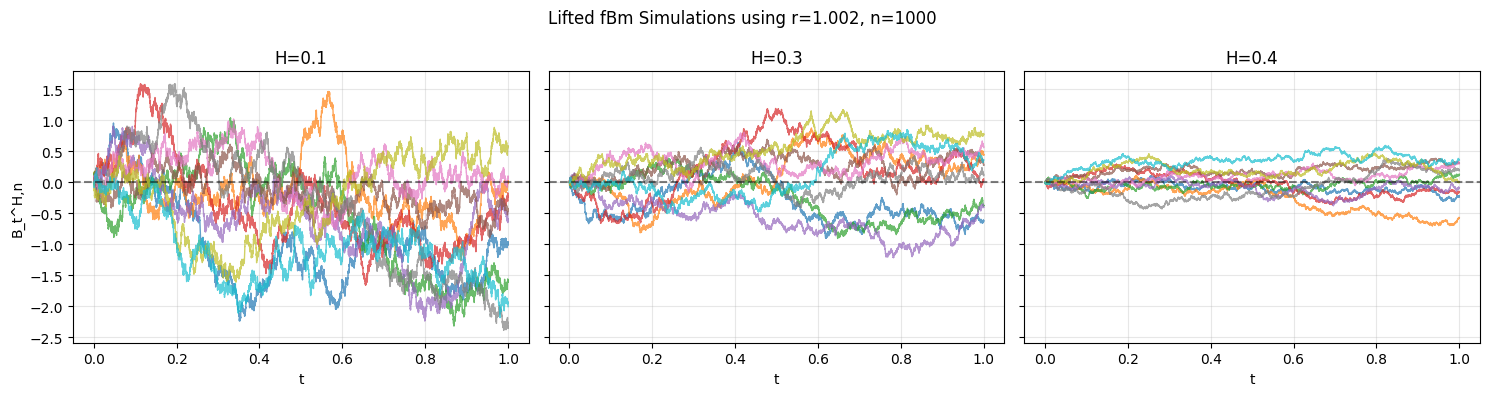

In [ ]:
def simulate_fBm_paths(H, r, n, T, n_steps, M, rng):
    """
    Simulate M fBm sample paths using the existing OU and weight machinery:
    B_t^{H,n} = sum_j w_j * (Z_t^{beta_j} - Z_0^{beta_j})

    Uses simulate_OU_paths (stationary start, correlated across beta_j)
    and OU_weights (nodes + quadrature weights) directly.
    """
    beta, w = OU_weights(H, r, n)

    # shape (M, n_steps+1, 2n) -- stationary_start=True gives correct correlated Z_0
    Z_path = simulate_OU_paths(beta, T, n_steps, M, rng, stationary_start=True)

    B_raw = Z_path @ w              # weighted sum over beta axis -> (M, n_steps+1)
    return B_raw - B_raw[:, [0]]    # subtract each path's own Z_0-contribution



# ---------- Simulation parameters ----------
T = 1
n_steps = 10000        # fine time grid to see roughness
r = 1.002
n = 1000       # many β nodes down to β_min ~ 1e-9
M_per_H = 10             # number of paths per H value

# Create a random generator with a fixed seed for reproducibility
rng = np.random.default_rng(42)

# Time points
times = np.linspace(0, T, n_steps + 1)

# Choose the Hurst parameters to compare
H_values = [0.1, 0.3, 0.4]

# ---------- Plotting ----------
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for idx, H in enumerate(H_values):
    # Simulate M paths for this H
    paths = simulate_fBm_paths(H, r, n, T, n_steps, M_per_H, rng)

    # Plot each path with a slight transparency
    for m in range(M_per_H):
        axes[idx].plot(times, paths[m], alpha=0.7, linewidth=1)

    axes[idx].set_title(f'H = {H}')
    axes[idx].set_xlabel('t')
    axes[idx].grid(alpha=0.3)
    axes[idx].axhline(0, color='black', linestyle='--', alpha=0.5)
    axes[idx].set_title(f"H={H}")

axes[0].set_ylabel('B_t^H,n')
plt.tight_layout()
fig.suptitle(f"Lifted fBm Simulations using r={r}, n_beta={n} ") #, fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 1])  # leave room at top for suptitle
plt.show()
plt.show()
plt.show()

# Validation

We validate that this is indeed (approximately) true fBm by checking the covariance. We do this by via monte carlo methods to calculate the covariance structure. In particular we simulate $M$ ($= 5000$) sample paths and create a monte carlo estimate of the covariance matrix using the following idea: 
$$C(i,j) = \operatorname{cov}(B_{t_i}^{H}, B_{t_j}^{H}) = \mathbb{E}[B_{t_i}^{H}, B_{t_j}^{H}]$$
So our monte carlo approximate covariance matrix is
$$ \hat{C}[i,j] = \frac{1}{M}\sum_{m=1}^{M} B_{\text{all}}[m,i] \cdot B_{\text{all}}[m,j] = \frac{1}{M}\left(B_{\text{all}}^{\top} B_{\text{all}}\right)[i,j] $$

In [6]:
def simulate_fBm_paths(H, r, n, T, n_steps, M, rng):
    beta, w = OU_weights(H, r, n)
    Z_path = simulate_OU_paths(beta, T, n_steps, M, rng, stationary_start=True)
    B_raw = Z_path @ w
    return B_raw - B_raw[:, [0]]

H = 0.3
r = 1.01
n = 100
T = 1.0
n_steps = 200
M = 5000

rng = np.random.default_rng(0)
B_all = simulate_fBm_paths(H, r, n, T, n_steps, M, rng)   # shape (M, n_steps+1)
times = np.linspace(0, T, n_steps + 1)

C_hat = (B_all.T @ B_all) / M      # shape (n_steps+1, n_steps+1)

We next normalize to ensure scaling/constants match the theoretical (fBm scaling is a bit fiddly so we fix it here).

In [7]:
target_var_at_t1 = 1.0**(2*H)     # = 1, from Var(B_t^H) = t^{2H}
empirical_var_at_t1 = C_hat[-1, -1]    # assuming T=1, last index is t=1
scale_correction = np.sqrt(target_var_at_t1 / empirical_var_at_t1)

B_all_calibrated = B_all * scale_correction
C_hat = (B_all_calibrated.T @ B_all_calibrated) / M

Reference covariance

In [8]:
def cov_true_fBm(s, t, H):
    return 0.5 * (s**(2*H) + t**(2*H) - abs(s - t)**(2*H))

C_true = np.array([[cov_true_fBm(si, tj, H) for tj in times] for si in times])

Comparison

max abs error: 0.08597374768946583
max rel error: 0.7888873284399875


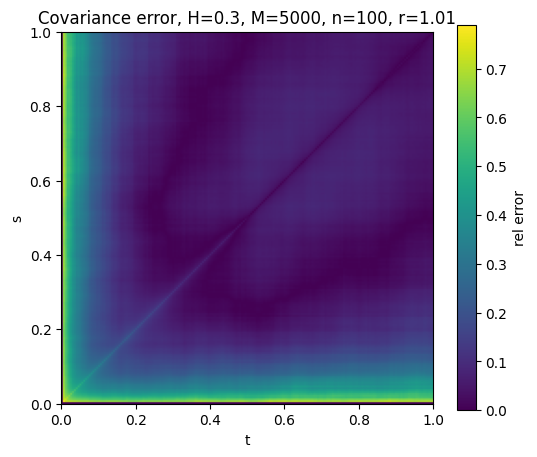

In [9]:
abs_err = np.abs(C_hat - C_true)
rel_err = abs_err / (np.abs(C_true) + 1e-10)

print("max abs error:", abs_err.max())
print("max rel error:", rel_err.max())

plt.figure(figsize=(6,5))
plt.imshow(rel_err, origin='lower', extent=[0, T, 0, T])
plt.colorbar(label="rel error")
plt.title(f"Covariance error, H={H}, M={M}, n={n}, r={r}")
plt.xlabel("t"); plt.ylabel("s")
plt.show()

We notice two key behaviors here:

- Along the diagonal $s \approx t$ we have a large error. this is because of the singularity in our fractional kernel since $Cov(B_s,B_t) = \int f_s(u)f_t(u) du$ where $f_s, f_t$ are our frational kernels that (as we saw above) are bad approximations near the singualirties $s = u$ and $t = u$, hence when $s = t = u$ we have a compound of these bad singularities which causes this large error.

- For small $s$ or small $t$ our covariances has a larger relative error, this is likely to be caused by the fact that the covariance is very small for smaller $s,t$ which would result in larger relative error.

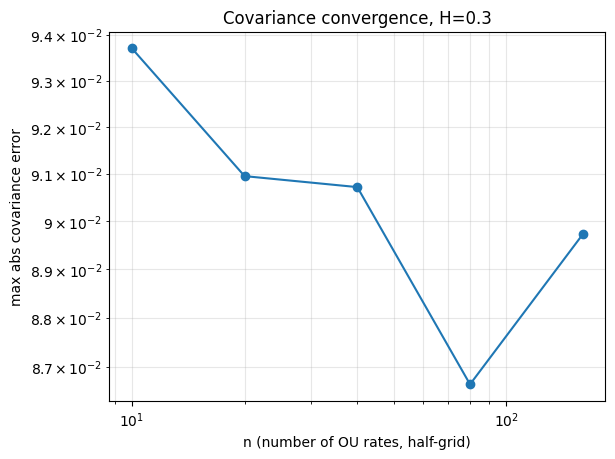

In [10]:
def max_cov_error(H, r, n, T, n_steps, M, rng):
    B = simulate_fBm_paths(H, r, n, T, n_steps, M, rng)
    C_hat = (B.T @ B) / M
    scale = np.sqrt(1.0 / C_hat[-1,-1])   # calibrate using t=T=1 point
    C_hat *= scale**2
    times = np.linspace(0, T, n_steps+1)
    C_true = np.array([[cov_true_fBm(si,tj,H) for tj in times] for si in times])
    return np.abs(C_hat - C_true).max()

ns = [10, 20, 40, 80, 160]
errors = []
for nn in ns:
    rr = 1 + 1/nn      # shrink r as n grows, tie them together sensibly
    e = max_cov_error(H, rr, nn, T, n_steps, M, np.random.default_rng(nn))
    errors.append(e)

plt.figure()
plt.loglog(ns, errors, 'o-')
plt.xlabel("n (number of OU rates, half-grid)")
plt.ylabel("max abs covariance error")
plt.title(f"Covariance convergence, H={H}")
plt.grid(True, which='both', alpha=0.3)
plt.show()

As we expect the covariance converges. However it unexpectedly goes back up. This because when our quadrature points becomes very close $\beta_i \approx beta_j$ our covariance cholesky matrix for OU  process $Z_0$ is $\Gamma_{i,j} = \frac1{\beta_i + \beta_j}$ will begin to become ill-condiitoned and have linearly dependent columns`which makes the cholesky decomposition algorithm break down.

In [11]:
for nn in ns:
    rr = 1 + 1/nn
    beta, w = OU_weights(H, rr, nn)
    Gamma = 1.0 / (beta[:,None] + beta[None,:])
    print(f"n={nn:4d}  cond(Gamma) = {np.linalg.cond(Gamma):.3e}")

n=  10  cond(Gamma) = 4.724e+18
n=  20  cond(Gamma) = 7.695e+19
n=  40  cond(Gamma) = 1.810e+19
n=  80  cond(Gamma) = 6.391e+19
n= 160  cond(Gamma) = 1.317e+20


# Conclusion

for $H < \frac12$ our OU approximation method is very accurate for reproducing fractional brownian motion. However we have innacuries for short lags and increasing $n$ beyond a certain point will actually cause more numerical problems.